# EDS 217, Lecture 1: Introduction to Python and Environmental Data Science

- Course Webpage: [https://eds-217-essential-python.github.io](https://eds-217-essential-python.github.io)


![data_science.jpg](assets/data_science.jpg)

![environmental_data_science.jpg](assets/environmental_data_science.jpg)

## Lecture Agenda

1. 🐍 What Python?
1. ❓ Why Python?
1. 💻 How Python?

> "Python is powerful... and fast; 
plays well with others; 
runs everywhere; 
is friendly & easy to learn; 
is Open."

## What is Python?

Python is a *general-purpose, object-oriented programming language* that emphasizes _code readability_ through its generous use of white space. Released in 1989, Python is easy to learn and a favorite of programmers and developers.



### High-level languages 
(Python, C, C++, Java, Javascript, R, Pascal)
- Take less time to write
- Shorter and easier to read
- Portable, meaning that they can run on different kinds of computers with few or no modifications.

The engine that translates and runs Python is called the *Python Interpreter*

In [1]:
""" 
Entering code into this notebook cell 
and pressing [SHIFT-ENTER] will cause the 
python interpreter to execute the code
"""



' \nEntering code into this notebook cell \nand pressing [SHIFT-ENTER] will cause the \npython interpreter to execute the code\n'

In [2]:
"""
Alternatively, you can run a 
any python script file (.py file)
so long as it contains valid
python code.
"""
!python hello_world.py

Hello world!
[from hello_world.py]


### Natural vs. Formal Languages

*Natural languages* are the languages that people speak. They are not designed (although they are subjected to various degrees of "order") and evolve naturally. 





*Formal languages* are languages that are designed by people for specific applications. 
- Mathematical Notation $E=mc^2$ 
- Chemical Notation: $\text{H}_2\text{O}$


*Programming languages* are **formal languages that have been designed to express computations**.



**Parsing**: The process of figuring out what the structure of a sentence or statement is (in a natural language you do this subconsciously). 


Formal Languages have **strict** syntax for _tokens_ and _structure_:

- Mathematical syntax error: $E=\$m🦆_2$ (bad tokens & bad structure)
- Chemical syntax error: $\text{G}_3\text{Z}$ (bad tokens, but structure is okay)

### Differences between Natural and Formal languages
1. _Ambiguity_:
Natural languages are full of ambiguity, which people parse using contextual clues. Formal languages are nearly or completely unambiguous; any statement has exactly one meaning, regardless of context.
1. _Redundancy_:
In order to make up for ambiguity, natural languages employ lots of redundancy. Formal languages are less redundant and more concise.
1. _Literalness_:
Formal languages mean exactly what they say. Natural languages employ idioms and metaphors.

The inherent differences between familiar natural languages and unfamiliar formal languages creates one of the greatest challenges in learning to code.

### A continuum of formalism
- _poetry_: Words are used for sound and meaning. Ambiguity is common and often deliberate.
- _prose_: The literal meaning of words is important, and the structure contributes meaning. Amenable to analysis but still often ambiguous.
- _program_: Meaning is unambiguous and literal, and can be understood entirely by analysis of the tokens and structure.

#### Strategies for parsing formal languages:
- **Formal languages are very dense**, so it takes longer to read them. 
- **Structure is very important**, so it is usually not a good idea to read from top to bottom, left to right. Instead, learn to parse the program in your head, identifying the tokens and interpreting the structure. 
- **Details matter**. Little things like spelling errors and bad punctuation, which you can get away with in natural languages, will make a big difference in a formal language.

## Why Python?



[IBM: R vs. Python](https://www.ibm.com/think/topics/python-vs-r)


Python is a multi-purpose language with a readable syntax that’s easy to learn. Programmers use Python to delve into data analysis or use machine learning in scalable production environments.

R is built by statisticians and leans heavily into statistical models and specialized analytics. Data scientists use R for deep statistical analysis, supported by just a few lines of code and beautiful data visualizations. 

In general, R is better for initial exploratory analyses, statistical analyses, and data visualization. 

In general, Python is better for working with APIs, writing maintainable, production-ready code, working with a diverse array of data, and building machine learning or AI workflows.

Both languages can _do_ anything. 
Most data science teams use both languages.
(and others too.. Matlab, Javascript, Go, Fortran, etc...)

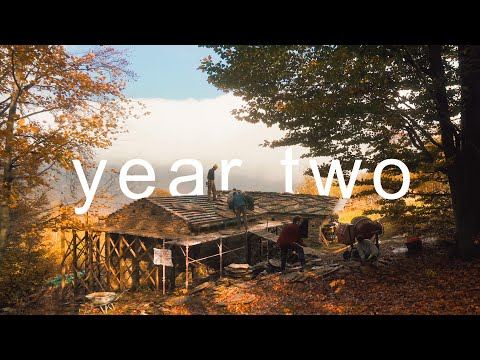

In [3]:
from IPython.lib.display import YouTubeVideo
YouTubeVideo('GVvfNgszdU0')

### Language usage by people who write code

Anaconda ran a *State of Data Science* survey for several years, and it published the raw
responses each time, but the last public data file is from 2023 and the survey stopped asking
which languages people use. The [Stack Overflow Developer
Survey](https://survey.stackoverflow.co/2025/technology) is the largest current alternative, and
it publishes its results openly. The 2025 edition collected answers from more than 49,000 people
in 177 countries.

The language question from that survey is on the course website as a small CSV. Let's do some
python data science!

In [ ]:
# First, we need to gather our tools
import pandas as pd  # This is the most common data science package used in python!
import matplotlib.pyplot as plt  # This is the most widely-used plotting package.

`pandas` can read a CSV file straight from a web address, so we do not have to download
anything first.

In [ ]:
url = "https://eds-217-essential-python.github.io/data/so_2025_language_usage.csv"
df = pd.read_csv(url)

# Our very first dataframe!
df.head()

# Jupyter notebook cells only output the last value requested...

In [ ]:
# Jupyter notebook cells only output the last value... unless you use print commands!
print(f'Number of rows: {len(df)}')
print(f'Number of columns: {len(df.columns)}')

Stack Overflow reports this question three times, once for everybody who answered and once for
each of two groups within them. Every row of our file says which group it belongs to, so the
first thing to find out is what those groups are.

In [ ]:
# What groups are in this file, and how many people are in each one?
df.groupby('group')['total_respondents'].first()

In [ ]:
# 1. Keep only the rows for everybody who answered
all_respondents = df[df['group'] == 'All Respondents'].copy()

# 2. Sort by percentage, and keep the fifteen most-used languages
top15 = all_respondents.sort_values('percent', ascending=False).head(15)

top15[['language', 'percent']]

In [ ]:
# Make the plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top15['language'], top15['percent'], color='#2C5F2D')
ax.invert_yaxis()  # Put the most-used language at the top

ax.set_xlabel('Percentage of respondents')
ax.set_title('Languages used in the past year, 2025', y=1.03)

plt.show()  # This command draws our figure.

Python is fourth in that chart. Before we decide what that means, we should look at the same
question for the people who said they are still learning to code.

In [ ]:
# Every group's answer for one language
df[df['language'] == 'Python'][['group', 'total_respondents', 'percent']]

In [ ]:
# Compare two of the groups across the languages that learners use most
groups = ['All Respondents', 'Learning to Code']
subset = df[df['group'].isin(groups)]

# Reshape the data so that each language is a row and each group is a column
comparison = subset.pivot(index='language', columns='group', values='percent')

# Keep the ten languages that people learning to code use most
comparison = comparison.sort_values('Learning to Code', ascending=False).head(10)

comparison

In [ ]:
# We are going to use the display command to update our figure over several cells.
# This usually isn't necessary, but it's helpful here to see how each set of
# commands updates the figure.
from IPython.display import display

fig, ax = plt.subplots(figsize=(9, 6))

comparison.sort_values('Learning to Code').plot(
    kind='barh', ax=ax, color=['#97BC62', '#2C5F2D'])

ax.set_xlabel('Percentage of respondents')
ax.set_ylabel('')
ax.set_title('Everyone who codes, and the people still learning', y=1.12)
ax.set_xlim(0, 85)  # Leave room on the right for the labels we add next

# Move the legend above the bars, so that it never sits on top of one
ax.legend(title=None, loc='lower right', bbox_to_anchor=(1.0, 1.0),
          ncol=2, frameon=False)

plt.show()

In [ ]:
# Add the percentage at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=9)

display(fig)  # This command shows our updated figure (we can't re-use "plt.show()")

In [ ]:
# Clean up the figure to remove spines and unecessary labels/ticks, etc..

# Remove the spines
for side in ['top', 'right', 'bottom']:
    ax.spines[side].set_visible(False)

# Remove the y-axis tick marks
ax.tick_params(axis='y', which='both', length=0)

# Remove the x-axis tick marks and labels, and the x-axis label
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax.set_xlabel('')

display(fig)  # Now 100% less visually cluttered!

Among everyone who answered, Python is fourth, at 57.9%, behind JavaScript, HTML/CSS and SQL.
Among the people who said they are learning to code, Python is first, at 71.8%. That second
group is the one you are in this week.

Stack Overflow also reports that Python rose seven percentage points between 2024 and 2025,
which they attribute to its use in AI, data science and back-end development.

Source: [Stack Overflow Developer Survey 2025](https://survey.stackoverflow.co/2025/technology).
The file we read is a tidy extract of the published results, taken from Stack Overflow's own
[data archive](https://github.com/StackExchange/Survey/tree/main/packages/archive/2025) and
licensed under the Open Database License.

# What python?

### Python Developer's Survey 2022
[JetBrains, Inc.](https://lp.jetbrains.com/python-developers-survey-2022/)

![image.png](assets/python_usage.png)

Data is [here](https://drive.google.com/drive/folders/17jyWjMslux6N921jXFI7-kdZzJ4L6vCI)

### Activities of Data Analysis...
[Anaconda State of Data Science](https://www.anaconda.com/state-of-data-science-2022)
![image.png](assets/activities.png)


# How Python?


Writing code requires an editor.

Running code requires an interpreter.

How you setup your editor and your interpreter can vary widely...

- On your machine? 
- On a server? 
- In the cloud? 
- In your browser? 
- In a file?

### Workflow for EDS 217

By end of this course, you will have learned the essentials of the python programming language, the main python data science library pandas, and basics of making figures using libraries that work with pandas dataframes. 

1. The next 9 days: Learn how to write code and get comfortable using Python.
1. Our class runs in Positron on the Bren server, where we write our code in Jupyter notebooks.
1. Eventually (later!) you can learn to manage python working environments using [conda](https://docs.conda.io/en/latest/)
1. You can also explore using .py files and other tools for developing your own functions and re-usable code.


## The End